In [ ]:
import pandas as pd
import requests
from io import BytesIO

def fetch_data_from_onedrive():
    url = 'https://1drv.ms/x/c/d25227ef9750cee4/EcAql4kIE7xPv_iBm5Msa5kBFy-ZAzjaf0jNREX_JJI-bw?download=1'
    response = requests.get(url)

    if response.status_code == 200:
        try:
            # for reading excel data
            df = pd.read_excel(
                BytesIO(response.content),
                sheet_name='Data In',
                skiprows=6,
                usecols='A:H',
                names=['TIME', 'Temperature', 'Humidity', 'AQI', 'Pressure', 'Wind Speed', 'Rainfall', 'Wind Dir'],
                parse_dates=['TIME']
            )

            # clean data
            df = df[df['TIME'].notna() & df['Temperature'].apply(lambda x: isinstance(x, (int, float)))]
            numeric_cols = ['Temperature', 'Humidity', 'Pressure', 'Wind Speed', 'Rainfall']
            df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
            df = df.dropna(subset=numeric_cols).drop(columns=['AQI'])

            return df.sort_values('TIME').reset_index(drop=True)

        except Exception as e:
            print(f"Data processing error: {e}")
            return None
    else:
        print(f"Failed to fetch data: HTTP {response.status_code}")
        return None

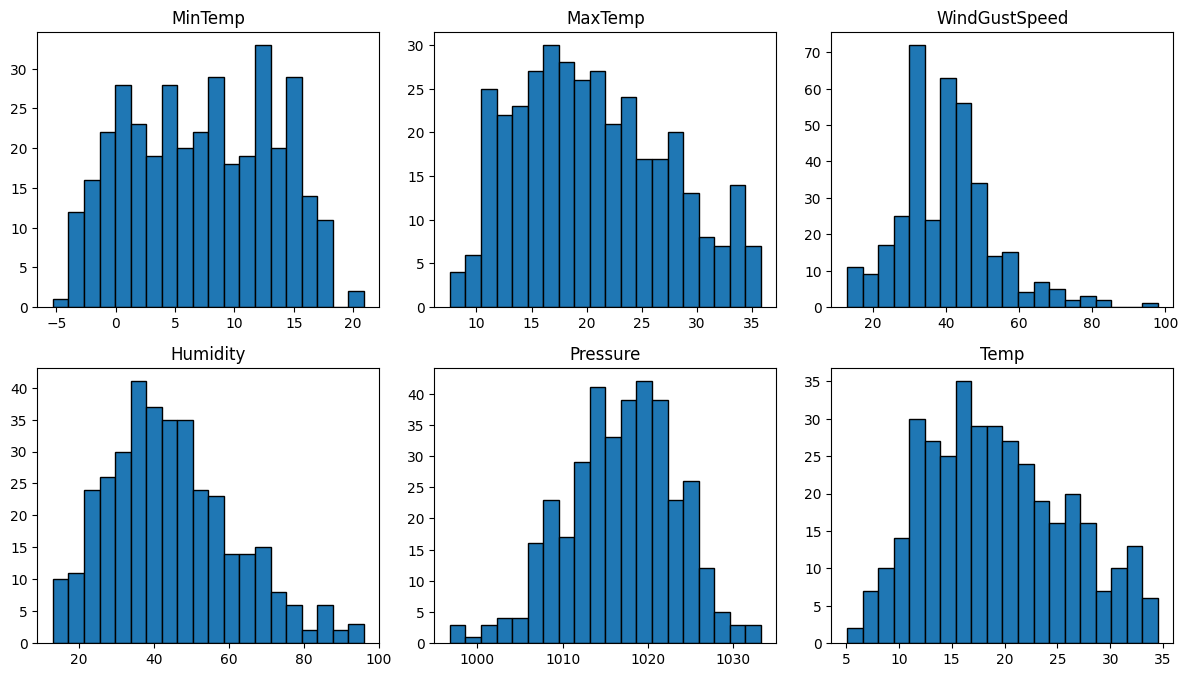

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta

def plot_5_hour_predictions(future_temp, future_humidity, timestamps):
    # plot 2 subplots
    plt.figure(figsize=(12, 6))

    # plot temp predictions
    plt.subplot(1, 2, 1)
    plt.plot(timestamps, future_temp, marker='o', color='red', label='Temperature (°C)')
    plt.title('5-Hour Temperature Forecast')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.grid(True)
    plt.xticks(rotation=45)  # rotate timestamps
    plt.legend()

    # plot humidity predictions
    plt.subplot(1, 2, 2)
    plt.plot(timestamps, future_humidity, marker='o', color='blue', label='Humidity (%)')
    plt.title('5-Hour Humidity Forecast')
    plt.xlabel('Time')
    plt.ylabel('Humidity (%)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()

    plt.tight_layout()
    plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# load the dataset
file_path = "weather.csv"
df = pd.read_csv(file_path)

# numerical columns
numerical_features = df.select_dtypes(include=['number'])

# histograms
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 10))
axes = axes.flatten()

for i, column in enumerate(numerical_features.columns):
    axes[i].hist(df[column], bins=20, edgecolor='black')
    axes[i].set_title(column)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 5.4 MB/s eta 0:00:00
Model Accuracy: 84.93%
Data successfully sent to ThingsBoard via REST API
Data successfully sent to ThingsBoard via MQTT

=== Weather Prediction ===
Current Temperature: 34.3°C
Rain Prediction: No

=== Temperature Forecast ===
23:29: 31.8°C
00:29: 27.2°C
01:29: 26.4°C
02:29: 21.6°C
03:29: 29.1°C

=== Humidity Forecast ===
23:29: 46.8%
00:29: 47.2%
01:29: 47.2%
02:29: 47.2%
03:29: 47.2%


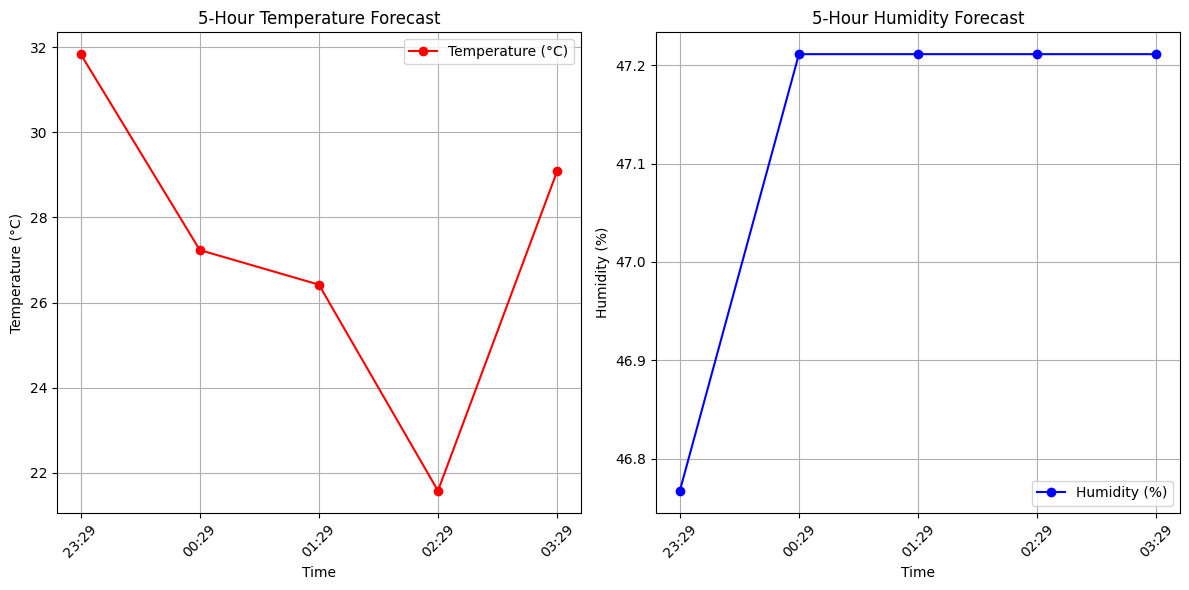

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error
from datetime import datetime, timedelta
import pytz
import requests
import json
!pip install paho-mqtt
import paho.mqtt.client as mqtt

# historical data csv
HISTORICAL_CSV_PATH = "/content/weather.csv"

# ThingsBoard info
THINGSBOARD_HOST = "www.ioTrendz.com"
ACCESS_TOKEN = "rhWg5IWBbsETBQU0zBk8"

# send data to ThingsBoard via REST API
def send_to_thingsboard_rest(data):
    url = f"https://{THINGSBOARD_HOST}/api/v1/{ACCESS_TOKEN}/telemetry"
    headers = {"Content-Type": "application/json"}

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))
        if response.status_code == 200:
            print("Data successfully sent to ThingsBoard via REST API")
        else:
            print(f"Failed to send data: {response.status_code} - {response.text}")
    except Exception as e:
        print(f"Error sending data to ThingsBoard: {str(e)}")

# send data to ThingsBoard via MQTT
def send_to_thingsboard_mqtt(data):
    client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2)
    client.username_pw_set(ACCESS_TOKEN)

    try:
        client.connect(THINGSBOARD_HOST, 1883, 60)
        client.publish("v1/devices/me/telemetry", json.dumps(data))
        print("Data successfully sent to ThingsBoard via MQTT")
        client.disconnect()
    except Exception as e:
        print(f"Error sending data via MQTT: {str(e)}")

# send predictions to ThingsBoard
def send_predictions_to_thingsboard(current_data, future_temp, future_humidity, rain_prediction):
    # current timestamp in ms
    timestamp = int(datetime.now().timestamp() * 1000)

    formatted_temp = {f"future_temperature_hour_{i+1}": round(temp, 2) for i, temp in enumerate(future_temp)}
    formatted_humidity = {f"future_humidity_hour_{i+1}": round(hum, 2) for i, hum in enumerate(future_humidity)}

    #ThingsBoard payload
    payload = {
        "ts": timestamp,
        "values": {
            "current_temperature": round(current_data['Temp'], 2),
            "current_humidity": round(current_data['Humidity'], 2),
            "current_pressure": round(current_data['Pressure'], 2),
            "rain_prediction": rain_prediction
        }
    }

    # merging payload
    payload["values"].update(formatted_temp)
    payload["values"].update(formatted_humidity)

    send_to_thingsboard_rest(payload)
    send_to_thingsboard_mqtt(payload)

def load_historical_data():
    try:
        df = pd.read_csv(HISTORICAL_CSV_PATH)
        df = df.dropna().drop_duplicates()
        return df
    except Exception as e:
        print(f"Error loading historical data: {str(e)}")
        return None

def process_onedrive_data(raw_data):
    if raw_data is None or raw_data.empty:
        return None

    # 5-minute intervals
    raw_data['group'] = (raw_data.index // 5)

    # aggregate data
    grouped = raw_data.groupby('group').agg({
        'Temperature': ['min', 'max', 'mean'],
        'Humidity': 'mean',
        'Pressure': 'mean',
        'Rainfall': 'mean'
    })

    # col names cleaning
    grouped.columns = ['MinTemp', 'MaxTemp', 'Temp', 'Humidity', 'Pressure', 'Rainfall_avg']

    grouped['WindGustDir'] = 'E'
    grouped['WindGustSpeed'] = 0.0
    grouped['RainTomorrow'] = grouped['Rainfall_avg'].apply(lambda x: 'Yes' if x > 0 else 'No')

    grouped['Date'] = pd.date_range(start="2015-01-01", periods=len(grouped), freq="5min")
    grouped.set_index('Date', inplace=True)

    return grouped[['MinTemp', 'MaxTemp', 'WindGustDir', 'WindGustSpeed',
                    'Humidity', 'Pressure', 'Temp', 'RainTomorrow']]

def prepare_data(data):
    le = LabelEncoder()
    data['WindGustDir'] = le.fit_transform(data['WindGustDir'])

    x = data[['MinTemp', 'MaxTemp', 'WindGustDir', 'WindGustSpeed',
              'Humidity', 'Pressure', 'Temp']]
    y = data['RainTomorrow']

    return x, y, le

def train_rain_model(x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(x_train, y_train)
    print(f"Model Accuracy: {model.score(x_test, y_test):.2%}")
    return model

def prepare_regression_data(data, feature):
    x, y = [], []
    for i in range(len(data) - 1):
        x.append(data[feature].iloc[i])
        y.append(data[feature].iloc[i + 1])
    return np.array(x).reshape(-1, 1), np.array(y)

def train_regression_model(x, y):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(x, y)
    return model

def predict_future(model, current_value):
    predictions = [current_value]
    for _ in range(5):
        next_val = model.predict([[predictions[-1]]])[0]
        predictions.append(next_val)
    return predictions[1:]

def weather_view():
    historical_data = load_historical_data()
    if historical_data is None:
        print("Failed to load historical data")
        return

    x, y, le = prepare_data(historical_data)
    rain_model = train_rain_model(x, y)

    raw_data = fetch_data_from_onedrive()
    if raw_data is None:
        print("Failed to fetch data from OneDrive")
        return

    processed_data = process_onedrive_data(raw_data)
    if processed_data is None:
        print("No valid data available for processing")
        return

    current_features = processed_data.iloc[-1][['MinTemp', 'MaxTemp', 'WindGustSpeed',
                                                'Humidity', 'Pressure', 'Temp']].copy()


    current_features['WindGustDir'] = le.transform([processed_data.iloc[-1]['WindGustDir']])[0]


    rain_prediction = rain_model.predict(pd.DataFrame([current_features], columns=x.columns))[0]

    x_temp, y_temp = prepare_regression_data(historical_data, 'Temp')
    x_hum, y_hum = prepare_regression_data(historical_data, 'Humidity')

    temp_model = train_regression_model(x_temp, y_temp)
    hum_model = train_regression_model(x_hum, y_hum)

    future_temp = predict_future(temp_model, current_features['Temp'])
    future_humidity = predict_future(hum_model, current_features['Humidity'])

    # Send predictions to ThingsBoard
    send_predictions_to_thingsboard(current_features, future_temp, future_humidity, rain_prediction)

    timezone = pytz.timezone('Asia/Karachi')
    current_time = datetime.now(timezone).replace(second=0, microsecond=0)
    timestamps = [current_time + timedelta(hours=i) for i in range(1, 6)]

    print("\n=== Weather Prediction ===")
    print(f"Current Temperature: {current_features['Temp']:.1f}°C")
    print(f"Rain Prediction: {'No' if rain_prediction else 'Yes'}")

    print("\n=== Temperature Forecast ===")
    for i, temp in enumerate(future_temp):
        print(f"{timestamps[i].strftime('%H:%M')}: {temp:.1f}°C")

    print("\n=== Humidity Forecast ===")
    for i, hum in enumerate(future_humidity):
        print(f"{timestamps[i].strftime('%H:%M')}: {hum:.1f}%")

    try:
        plot_5_hour_predictions(future_temp, future_humidity, [ts.strftime('%H:%M') for ts in timestamps])
    except Exception as e:
        print(f"Could not generate long-term predictions: {str(e)}")

if __name__ == "__main__":
    weather_view()